# Figure 7.5-2 &mdash; The vapor pressure of *n*-butane

This notebook recreates **Figure 7.5-2**: the vapor pressure of *n*-butane as a
function of temperature, plotted as $\ln P^{\mathrm{vap}}$ against $1/T$, with the
experimental data compared against three equation-of-state predictions:

| curve | equation of state |
|:--:|---|
| **a** | van der Waals |
| **b** | Peng&ndash;Robinson with $\alpha = 1$ |
| **c** | Peng&ndash;Robinson with the full $\alpha(T)$ of Eq. 6.7-1 |

All three use exactly the same calculation &mdash; the equal-fugacity condition of
Sec. 7.4 solved at each temperature, which is the algorithm of the flow sheet in
**Figure 7.5-1**. Only the equation of state supplying $\underline{V}(T,P)$ and
$f(T,P)$ changes. The figure is therefore a controlled comparison: it isolates what
the temperature dependence of the $a$ parameter buys you.

The axes are $\log P^{\mathrm{vap}}$ versus $1/T$ rather than $P^{\mathrm{vap}}$
versus $T$ because the Clausius&ndash;Clapeyron equation (Eq. 7.7-6) makes
$\ln P^{\mathrm{vap}}$ nearly linear in $1/T$; see Sec. 7.7. Straight lines make the
disagreement between the three models easy to see over four decades of pressure.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## Properties of *n*-butane

The critical constants and acentric factor are the values in SIS Table 6.6-1
(they also appear in `code/data/pure_property.csv`). Everything below is in SI:
$T$ in K, $P$ in Pa, $\underline{V}$ in m $^3$/mol.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import brentq
from numpy.polynomial import Polynomial

# Typography, matching the other recomputed figures (Figs. 6.6-1, 7.3-1 to 7.3-4): use a
# real LaTeX installation when there is one, so the figure is set in Computer Modern like
# the book, and fall back to matplotlib's own mathtext otherwise — the notebook still runs
# in Colab, which has no TeX. The fallback keeps a serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

R = constants.R    # gas constant, J/(mol K)
BAR = 1e5          # Pa per bar
SQRT2 = np.sqrt(2.0)

# n-butane (SIS Table 6.6-1)
Tc = 425.2         # K
Pc = 38.0e5        # Pa
omega = 0.199      # acentric factor
Tb = 272.65        # normal boiling temperature, K (used only as a check)

print(f"n-butane: Tc = {Tc} K, Pc = {Pc/BAR:.1f} bar, omega = {omega}")
print(f"LaTeX typesetting: {'on (Computer Modern)' if mpl.rcParams['text.usetex'] else 'off (mathtext fallback)'}")

n-butane: Tc = 425.2 K, Pc = 38.0 bar, omega = 0.199
LaTeX typesetting: on (Computer Modern)


## The two equations of state

### van der Waals

$$ P = \frac{RT}{\underline{V}-b} - \frac{a}{\underline{V}^{2}} $$

with the critical-point constraints fixing the constants,

$$ a = \frac{27}{64}\frac{R^{2}T_c^{2}}{P_c}, \qquad b = \frac{RT_c}{8P_c} $$

Note that $a$ carries **no temperature dependence at all**. In terms of the
compressibility factor $Z = P\underline{V}/RT$ the equation is the cubic

$$ Z^{3} - (1+B)Z^{2} + AZ - AB = 0, \qquad
   A = \frac{aP}{(RT)^{2}}, \quad B = \frac{bP}{RT} $$

and the fugacity coefficient is (SIS Table 7.4-1)

$$ \ln\frac{f}{P} = (Z-1) - \ln(Z-B) - \frac{A}{Z} $$

### Peng&ndash;Robinson

$$ P = \frac{RT}{\underline{V}-b} -
   \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

$$ b = 0.07780\,\frac{RT_c}{P_c} \tag{Eq. 6.7-2}$$
$$ a(T) = 0.45724\,\frac{R^{2}T_c^{2}}{P_c}\,\alpha(T) \tag{Eq. 6.7-1}$$
$$ \sqrt{\alpha} = 1 + \kappa\left(1-\sqrt{T/T_c}\right) \tag{Eq. 6.7-3}$$
$$ \kappa = 0.37464 + 1.54226\,\omega - 0.26992\,\omega^{2} \tag{Eq. 6.7-4}$$

$$ Z^{3} + (B-1)Z^{2} + (A - 3B^{2} - 2B)Z + (-AB + B^{2} + B^{3}) = 0
   \tag{Eq. 6.4-4, Table 6.4-3}$$

$$ \ln\frac{f}{P} = (Z-1) - \ln(Z-B) - \frac{A}{2\sqrt{2}B}
   \ln\!\left[\frac{Z+(1+\sqrt{2})B}{Z+(1-\sqrt{2})B}\right] $$

Setting $\alpha = 1$ (curve **b**) freezes $a$ at its critical-point value
$a(T_c)$, which is the van der Waals *idea* of a temperature-independent
attraction wearing the Peng&ndash;Robinson volume dependence. Comparing **b** with
**c** separates the effect of $\alpha(T)$ from the effect of the improved
$\underline{V}$ dependence.

Each equation of state is packaged as a small dictionary of four callables, so the
saturation-pressure routine below can be written **once** and handed any of them.

In [2]:
def real_roots(roots):
    """Keep the real roots of the cubic, ascending. The tolerance is scaled to the
    root magnitude: near Tc the three real roots crowd together and pick up tiny
    numerical imaginary parts that a fixed tolerance would reject."""
    keep = np.abs(roots.imag) < 1e-9 * np.maximum(1.0, np.abs(roots.real))
    return np.sort(roots.real[keep])


# --- van der Waals -------------------------------------------------------
def vdw_ab():
    """a (Pa m^6/mol^2) and b (m^3/mol) from the critical-point constraints."""
    return 27 * R**2 * Tc**2 / (64 * Pc), R * Tc / (8 * Pc)


def vdw_P(V, T):
    a, b = vdw_ab()
    return R * T / (V - b) - a / V**2


def vdw_Z(P, T):
    """Real compressibility roots (ascending), with A and B."""
    a, b = vdw_ab()
    A = a * P / (R * T)**2
    B = b * P / (R * T)
    # coefficients in increasing order: c0 + c1 Z + c2 Z^2 + Z^3
    roots = Polynomial([-A * B, A, -(1 + B), 1]).roots()
    return real_roots(roots), A, B


def vdw_lnphi(Z, A, B):
    return (Z - 1) - np.log(Z - B) - A / Z


# --- Peng-Robinson -------------------------------------------------------
def PR_ab(T, alpha_on=True):
    """a(T) and b. alpha_on=False freezes a at a(Tc), i.e. alpha = 1."""
    b = 0.07780 * R * Tc / Pc
    if alpha_on:
        kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
        alpha = (1 + kappa * (1 - np.sqrt(T / Tc)))**2
    else:
        alpha = 1.0
    return 0.45724 * R**2 * Tc**2 / Pc * alpha, b


def PR_P(V, T, alpha_on=True):
    a, b = PR_ab(T, alpha_on)
    return R * T / (V - b) - a / (V * (V + b) + b * (V - b))


def PR_Z(P, T, alpha_on=True):
    a, b = PR_ab(T, alpha_on)
    A = a * P / (R * T)**2
    B = b * P / (R * T)
    roots = Polynomial([-A * B + B**2 + B**3, A - 3 * B**2 - 2 * B, -1 + B, 1]).roots()
    return real_roots(roots), A, B


def PR_lnphi(Z, A, B):
    return (Z - 1) - np.log(Z - B) - A / (2 * SQRT2 * B) * np.log(
        (Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


# One dictionary per curve of Figure 7.5-2. Packaging each equation of state this
# way lets the saturation-pressure routine below be written once and handed any
# of them, so the three curves differ ONLY in the equation of state.
EOS = {
    "a": dict(label="van der Waals",
              P=vdw_P, Z=vdw_Z, lnphi=vdw_lnphi, b=lambda: vdw_ab()[1]),
    "b": dict(label=r"Peng-Robinson, $\alpha = 1$",
              P=lambda V, T: PR_P(V, T, False), Z=lambda P, T: PR_Z(P, T, False),
              lnphi=PR_lnphi, b=lambda: PR_ab(Tc, False)[1]),
    "c": dict(label=r"Peng-Robinson, $\alpha(T)$",
              P=lambda V, T: PR_P(V, T, True), Z=lambda P, T: PR_Z(P, T, True),
              lnphi=PR_lnphi, b=lambda: PR_ab(Tc, True)[1]),
}

kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
print(f"kappa = {kappa:.4f}")
print(f"vdW    a = {vdw_ab()[0]:.4f} Pa m^6/mol^2,  b = {vdw_ab()[1]*1e6:.2f} cm^3/mol")
print(f"PR     a(Tc) = {PR_ab(Tc)[0]:.4f} Pa m^6/mol^2,  b = {PR_ab(Tc)[1]*1e6:.2f} cm^3/mol")

kappa = 0.6709
vdW    a = 1.3876 Pa m^6/mol^2,  b = 116.29 cm^3/mol
PR     a(Tc) = 1.5039 Pa m^6/mol^2,  b = 72.38 cm^3/mol


## Saturation pressure: the algorithm of Figure 7.5-1

At a chosen temperature the vapor pressure is the one pressure at which the liquid
and vapor fugacities are equal,

$$ f^{\mathrm{L}}(T,P^{\mathrm{vap}}) = f^{\mathrm{V}}(T,P^{\mathrm{vap}})
   \qquad\Longleftrightarrow\qquad
   \ln\frac{f^{\mathrm{L}}}{P} - \ln\frac{f^{\mathrm{V}}}{P} = 0 $$

where $Z^{\mathrm{L}}$ is the smallest and $Z^{\mathrm{V}}$ the largest real root of
the cubic. That is the residual whose zero the flow sheet of Fig. 7.5-1 hunts for.

**The trivial solution.** Sec. 7.5 warns that the initial guess must be made with
care: the guessed pressure has to lie inside the van der Waals loop, or the cubic
returns only *one* real root, the "liquid" and "vapor" phases come back identical,
and the iteration happily converges on a one-phase pressure that is not the vapor
pressure. The danger grows as $T \to T_c$, where the loop shrinks to nothing.

Rather than guess, we **remove the guess**. For $T < T_c$ the sub-critical isotherm
has a local pressure maximum (the liquid spinodal) and a local minimum (the vapor
spinodal); three real roots exist between them, and $P^{\mathrm{vap}}$ always lies
in that interval. Locating the two turning points brackets the root by
construction, and bisection (`brentq`) then cannot escape to the trivial solution.
This is the systematic cure for the trap the text describes, and it is what lets
one routine run all three equations of state from $0.44\,T_c$ to the critical point
without any hand-tuned starting values.

In [3]:
def spinodal_bounds(eos, T, n=20000):
    """Pressures at the local max and min of the sub-critical isotherm loop.
    Returns None once the loop has vanished (T >= Tc)."""
    b = eos["b"]()
    V = np.logspace(np.log10(1.0000001 * b), 3.0, n)   # just above b, out to 1e3 m^3/mol
    P = eos["P"](V, T)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]   # dP/dV changes sign
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def fugacity_residual(eos, T, P):
    """ln(f_L/P) - ln(f_V/P). NaN if the cubic has no two distinct phase roots."""
    Z, A, B = eos["Z"](P, T)
    Z = Z[Z > B]                       # a root below B is not physical
    if len(Z) < 2:
        return np.nan
    return eos["lnphi"](Z.min(), A, B) - eos["lnphi"](Z.max(), A, B)


def Psat(eos, T):
    """Vapor pressure (Pa) at T (K) by equal fugacity, bracketed between the
    spinodals. Returns None if no two-phase solution exists."""
    bounds = spinodal_bounds(eos, T)
    if bounds is None:
        return None
    P_lo, P_hi = bounds
    P_lo = max(P_lo, 1e-10 * BAR)      # the vapor spinodal pressure can be negative

    # Walk the ends inward until both give a usable residual of opposite sign.
    for _ in range(200):
        r_lo, r_hi = (fugacity_residual(eos, T, P_lo),
                      fugacity_residual(eos, T, P_hi))
        if np.isfinite(r_lo) and np.isfinite(r_hi) and r_lo * r_hi < 0:
            break
        if not np.isfinite(r_lo):
            P_lo *= 1.5
        if not np.isfinite(r_hi):
            P_hi *= 0.999
        if P_hi <= P_lo:
            return None
    else:
        return None

    return brentq(lambda P: fugacity_residual(eos, T, P), P_lo, P_hi,
                  xtol=1e-12, rtol=1e-12)


def phase_volumes(eos, T, P):
    """Saturated liquid and vapor molar volumes (m^3/mol) at T, P."""
    Z, A, B = eos["Z"](P, T)
    Z = Z[Z > B]
    return Z.min() * R * T / P, Z.max() * R * T / P


# A first check: the complete Peng-Robinson equation at the normal boiling point,
# where the answer should be one atmosphere.
P = Psat(EOS["c"], Tb)
vL, vV = phase_volumes(EOS["c"], Tb, P)
print(f"PR alpha(T):  Psat({Tb} K) = {P/BAR:.4f} bar   (1 atm = {constants.atm/BAR:.4f} bar)")
print(f"              vL = {vL*1e6:.1f} cm^3/mol,  vV = {vV*1e3:.2f} L/mol")

PR alpha(T):  Psat(272.65 K) = 1.0164 bar   (1 atm = 1.0132 bar)
              vL = 91.6 cm^3/mol,  vV = 21.50 L/mol


## Experimental vapor pressures

The measured vapor pressures are the **saturation table for *n*-butane from the NIST
Chemistry WebBook**, generated from the reference equation of state of

> A. Bücker and W. Wagner, "Reference Equations of State for the Thermodynamic
> Properties of Fluid Phase *n*-Butane and Isobutane," *J. Phys. Chem. Ref. Data*
> **35**, 929–1019 (2006).

A reference equation of state is a high-order correlation fitted to the whole body of
measured $p\rho T$ and saturation data for one fluid, and it reproduces the
vapor-pressure measurements to about 0.1% — far closer than the plotting accuracy of
this figure. It is the standard stand-in for "the experimental data," and it is what
the squares below are.

Retrieved from
<https://webbook.nist.gov/cgi/fluid.cgi?ID=C106978&Action=Page> (*n*-butane,
CAS 106-97-8); NIST data are US Government work and not subject to copyright.

Two notes on consistency:

- Bücker and Wagner give $T_c = 425.125$ K and $P_c = 37.96$ bar, marginally different
  from the SIS Table 6.6-1 values ($425.2$ K, $38.0$ bar) used for the equations of
  state above. The difference is well under the width of a plotted symbol; the EOS
  curves keep the book's constants so the calculation matches the text.
- The table stops at 420 K rather than $T_c$, because the last few kelvin below the
  critical point compress four decades of curvature into a sliver and add nothing
  legible to the figure.

In [4]:
# Experimental vapor pressure of n-butane.
# NIST Chemistry WebBook saturation table (CAS 106-97-8), from the reference EOS of
# Bucker & Wagner, J. Phys. Chem. Ref. Data 35, 929 (2006). T in K, P in bar.
data = pd.DataFrame({
    "T": [180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300,
          310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420],
    "P": [0.0033476, 0.0084976, 0.019390, 0.040426, 0.078045, 0.14106,
          0.24086, 0.39153, 0.60977, 0.91481, 1.3282, 1.8734, 2.5760,
          3.4628, 4.5624, 5.9045, 7.5201, 9.4417, 11.704, 14.343, 17.399,
          20.918, 24.954, 29.578, 34.897],
})
data["1000/T"] = 1000 / data["T"]


def P_data(T):
    """Experimental vapor pressure (bar), log-interpolated in 1/T between the
    tabulated points — the natural interpolation on these axes, where the data are
    very nearly a straight line. (T ascending means 1000/T descends, and np.interp
    needs an ascending abscissa, hence the reversal.)"""
    xp = data["1000/T"].to_numpy()[::-1]
    fp = np.log10(data["P"].to_numpy())[::-1]
    return 10**np.interp(1000 / np.asarray(T, dtype=float), xp, fp)


print(f"{len(data)} experimental points, {data['T'].min():.0f}-{data['T'].max():.0f} K, "
      f"{data['P'].min():.4g}-{data['P'].max():.4g} bar")
print(f"at the normal boiling point Tb = {Tb} K:  {float(P_data(Tb)):.4f} bar "
      f"(1 atm = {constants.atm/BAR:.4f} bar)")

25 experimental points, 180-420 K, 0.003348-34.9 bar
at the normal boiling point Tb = 272.65 K:  1.0125 bar (1 atm = 1.0132 bar)


## The three predictions side by side

Before plotting, tabulate the vapor pressures against the measured values at every
other tabulated temperature. The pattern is already clear in the numbers: at the
critical point all three equations agree by construction, but as the temperature
falls the two constant-$a$ models drift high by more than an order of magnitude,
while the complete Peng&ndash;Robinson equation stays within a few percent of the
data everywhere.

In [5]:
rows = []
for T, P_exp in zip(data["T"], data["P"]):
    if T % 20:                        # every other tabulated point, to keep it short
        continue
    row = {"T (K)": T, "1000/T": 1000 / T, "exp (bar)": P_exp}
    for key in "abc":
        P = Psat(EOS[key], float(T))
        row[f"{key} (bar)"] = P / BAR if P else np.nan
        row[f"{key} err %"] = 100 * (P / BAR - P_exp) / P_exp if P else np.nan
    rows.append(row)

table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format=lambda x: f"{x:.4g}"))

err_c = table["c err %"].abs()
print(f"\ncomplete Peng-Robinson: mean |error| {err_c.mean():.2f}%, "
      f"worst {err_c.max():.2f}% (at {table.loc[err_c.idxmax(), 'T (K)']:.0f} K)")

 T (K)  1000/T  exp (bar)  a (bar)  a err %  b (bar)  b err %  c (bar)   c err %
   180   5.556   0.003348    0.312     9219   0.2156     6339 0.003713     10.92
   200       5    0.01939     0.69     3458   0.5077     2519  0.02059     6.169
   220   4.545    0.07805    1.327     1600    1.027     1216  0.08066     3.356
   240   4.167     0.2409    2.299    854.3    1.855    670.2   0.2449     1.685
   260   3.846     0.6098    3.679    503.4    3.075    404.3   0.6141    0.7172
   280   3.571      1.328    5.536    316.8    4.769      259    1.331    0.2004
   300   3.333      2.576     7.93    207.8    7.013    172.3    2.576 -0.001011
   320   3.125      4.562    10.91    139.2    9.883    116.6    4.563   0.01956
   340   2.941       7.52    14.54     93.3    13.45    78.85    7.535    0.1943
   360   2.778       11.7    18.84    60.96    17.78    51.92    11.76    0.4582
   380   2.632       17.4    23.86    37.12    22.94    31.86    17.53    0.7263
   400     2.5      24.95   

## Figure 7.5-2

The curves are computed on a grid evenly spaced in $1/T$ &mdash; the plotting
variable &mdash; so they are drawn with uniform resolution across the figure. They
span the experimental table, from 180 K up to $0.9995\,T_c$; the upper limit stops
just short of $T_c$, where the loop the solver brackets closes up.

The axes reproduce the printed figure: $1000/T$ from 2 to 6 and $P^{\mathrm{vap}}$
from $10^{-3}$ to $10^{2}$ bar, with temperature itself on a second abscissa across
the top.

A high-resolution PDF is written to `pdf/Fig_7.5-2.pdf`.

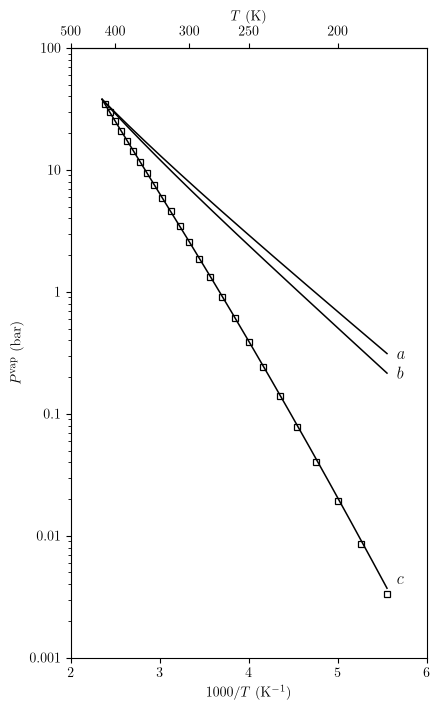

In [6]:
import os
from matplotlib.ticker import FixedLocator, FuncFormatter

INV_LO, INV_HI = 2.0, 6.0          # 1000/T axis limits, matching the printed figure
P_LO, P_HI = 1e-3, 100             # bar, matching the printed figure
T_LO = data["T"].min()             # 180 K, the low end of the experimental table
T_HI = 0.9995 * Tc                 # just below the critical point
BLACK = "black"

# offsets (in points) that keep each curve's label clear of the axes frame
LABEL_OFFSET = {"a": (7, -1), "b": (7, -1), "c": (7, 6)}


def vapor_pressure_curve(eos, n=160):
    """Psat along a grid uniform in 1000/T. Returns (1000/T, P in bar)."""
    inv = np.linspace(1000 / T_HI, 1000 / T_LO, n)
    P = np.array([Psat(eos, 1000 / x) or np.nan for x in inv])
    return inv, P / BAR


# aspect ratio and axes limits match Fig. 7.5-2 in the 5th edition
fig, ax = plt.subplots(figsize=(4.5, 7.2))

# --- experimental data (open squares, as in the book) ---
ax.plot(data["1000/T"], data["P"], "s", mfc="none", mec=BLACK, ms=5, mew=0.9,
        label="experimental data", zorder=3)

# --- the three equation-of-state predictions, labeled a, b, c at their ends ---
# The keys are set in math mode rather than with style="italic", so they come out as
# true Computer Modern italic under LaTeX and as CM math in the fallback.
for key in "abc":
    inv, P = vapor_pressure_curve(EOS[key])
    ax.plot(inv, P, "-", color=BLACK, lw=1.1, label=EOS[key]["label"])
    ok = np.isfinite(P)
    ax.annotate(rf"${key}$", xy=(inv[ok][-1], P[ok][-1]), xytext=LABEL_OFFSET[key],
                textcoords="offset points", fontsize=12, ha="left", va="center")

ax.set_yscale("log")
ax.set_xlim(INV_LO, INV_HI)
ax.set_ylim(P_LO, P_HI)
ax.set_xticks([2, 3, 4, 5, 6])
ax.set_xlabel(r"$1000/T$  (K$^{-1}$)")
ax.set_ylabel(r"$P^{\mathrm{vap}}$  (bar)")

# decade labels as plain decimals (0.001, 0.01, ...), as the book prints them
ax.yaxis.set_major_locator(FixedLocator([1e-3, 1e-2, 1e-1, 1, 10, 100]))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda y, _: f"{y:g}" if y >= 1 else f"{y:.10g}"))

# --- second abscissa: temperature itself, at 1000/T positions ---
top = ax.secondary_xaxis("top", functions=(lambda x: x, lambda x: x))
T_ticks = [500, 400, 300, 250, 200]
top.set_xticks([1000 / t for t in T_ticks])
top.set_xticklabels([f"{t}" for t in T_ticks])
top.set_xlabel(r"$T$  (K)")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_7.5-2.pdf", dpi=300, bbox_inches="tight")
plt.show()

## What the figure shows

**The van der Waals equation (a) is poor, and freezing $\alpha$ is most of the
reason.** Curve **b** is the Peng&ndash;Robinson volume dependence with a
temperature-independent $a$, and it sits almost on top of curve **a**: the
Peng&ndash;Robinson improvement to the $\underline{V}$ dependence buys very little
of the vapor-pressure accuracy on its own. Almost all of the gap between **b** and
**c** &mdash; more than a decade in pressure at 200 K &mdash; comes from
$\alpha(T)$.

That is by design, and it is worth being clear about what kind of success it is.
The functional form of Eq. 6.7-3 was *chosen*, and $\kappa$ *correlated against the
acentric factor*, precisely so that a cubic equation of state would reproduce
vapor pressures over the whole subcritical range. Curve **c** agreeing with the
data is a well-fitted correlation performing as advertised, not a prediction from
first principles. The two constraints visible in the figure are the ones built in:
$\alpha(T_c) = 1$ forces all three curves through the critical point, and the
$\sqrt{\alpha}$ form is what keeps the agreement good all the way down.

**All three curves are nearly straight.** Eq. 7.7-6, the integrated
Clausius&ndash;Clapeyron equation, predicts $\ln P^{\mathrm{vap}}$ linear in $1/T$
with slope $-\Delta^{\mathrm{vap}}\underline{H}/R$. The residual curvature is real:
$\Delta^{\mathrm{vap}}\underline{H}$ is not constant, and it vanishes at the
critical point. Sec. 7.7 takes this up.

### Things to try

1. Fit a straight line to curve **c** over a limited range and recover
   $\Delta^{\mathrm{vap}}\underline{H}$ from its slope. Compare with the enthalpy of
   vaporization from the departure functions of Ch. 6, or with a handbook value.
2. Repeat the calculation for the Soave&ndash;Redlich&ndash;Kwong equation
   (Eqs. 6.7-6 to 6.7-8) and add it as a fourth curve &mdash; this is
   Problems 7.51, 7.52 and 7.58.
3. Swap in a different fluid. Change `Tc`, `Pc` and `omega`, and replace the `data`
   table with the NIST WebBook saturation table for the new fluid. A quick
   alternative source of comparison data is the four-constant **Wagner correlation**
   carried in `code/data/pure_property.csv` (columns `VpA`&ndash;`VpD` with
   `Eq = 1`), which reproduces the reference values for *n*-butane to better than 1%.
   A strongly polar or hydrogen-bonding fluid (water, ammonia) is the interesting
   test of how far the $\kappa(\omega)$ correlation carries.
4. Delete the bracketing in `Psat` and use `scipy.optimize.newton` with a fixed
   starting guess instead. Find a temperature where it converges to the trivial
   solution, and confirm from the returned roots that the two "phases" are
   identical &mdash; the failure Sec. 7.5 warns about.